This will have the CCF ACF and PACF for the plots.
We start off by plotting the acf of the plots to show the similarity of the lags.

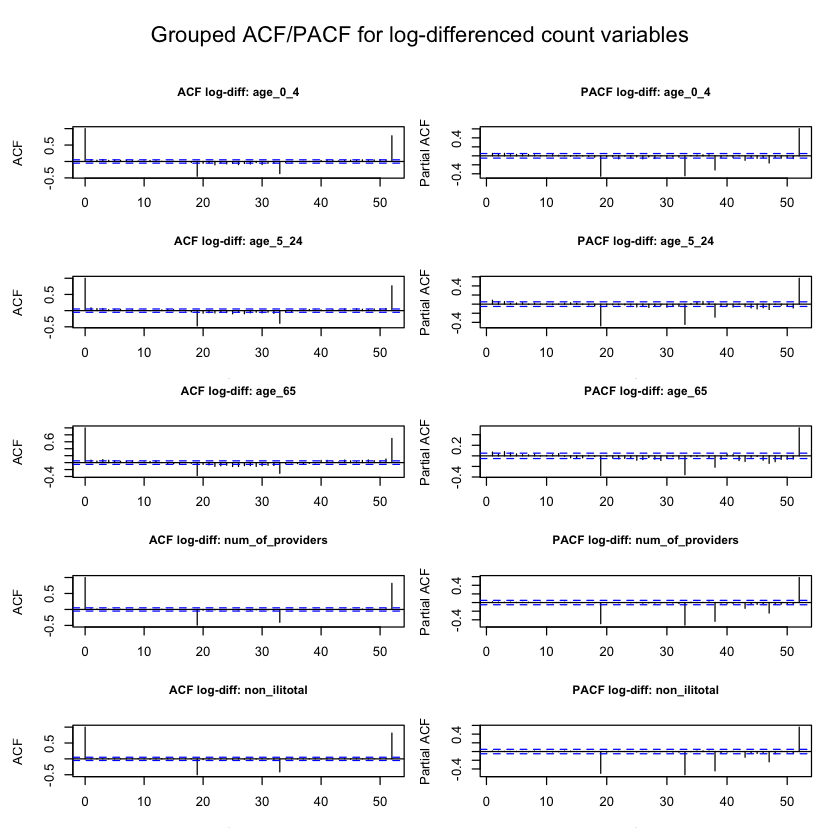

In [1]:
fdf <- read.csv("data/fluview_clean/ilinet_final.csv")

# Group ACF/PACF plots for log-differenced count variables
variables <- c("age_0_4", "age_5_24", "age_65", "num_of_providers", "non_ilitotal")
old_par <- par(no.readonly = TRUE)
on.exit(par(old_par))
# More vertical spacing between panels + larger top outer margin
par(
  mfrow = c(length(variables), 2),
  mar = c(3.2, 3.8, 3.0, 1),
  oma = c(0.8, 0.8, 5.0, 0.8),
  cex.main = 0.9
)

for (v in variables) {
  x <- fdf[[v]]
  ld <- diff(x)
  acf(ld, lag.max = 52, main = paste("ACF log-diff:", v))
  pacf(ld, lag.max = 52, main = paste("PACF log-diff:", v))
}

mtext("Grouped ACF/PACF for log-differenced count variables", outer = TRUE, cex = 1.1, line = 2.2)

My point is clearly there is just one significant difference at lag 19 for each of these plots and 52. The other difference comes at 33 which is just 52-19 thus by harmonics

## Sliding acf
Now I want to do some sort look at a sliding acf of the log-differenced  to check if the relationship is changing over time.
Note when we look at the acf we are only seeing an average over the lags.